<a href="https://colab.research.google.com/github/TamirPalay/DI_Exercises/blob/main/week11/day1-2/GenAI_197_W11D1_Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Importing the libraries

In [ ]:
# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, GRU
from keras.optimizers import SGD, Adam
import math
from sklearn.metrics import mean_squared_error

## Utility Functions

In [ ]:
def plot_predictions(test,predicted):
    plt.plot(test, color='red',label='Real IBM Stock Price')
    plt.plot(predicted, color='blue',label='Predicted IBM Stock Price')
    plt.title('IBM Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('IBM Stock Price')
    plt.legend()
    plt.show()

def return_rmse(test,predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {}.".format(rmse))

## Loading and Preprocessing the Data

In [ ]:
!wget https://github.com/devtlv/Datasets-GEN-AI-Bootcamp/raw/refs/heads/main/Week%206/W6D4/Intro%20to%20Recurrent%20Neural%20Networks%20LSTM%20%20GRU.zip

--2026-07-02 17:05:00--  https://github.com/devtlv/Datasets-GEN-AI-Bootcamp/raw/refs/heads/main/Week%206/W6D4/Intro%20to%20Recurrent%20Neural%20Networks%20LSTM%20%20GRU.zip
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://media.githubusercontent.com/media/devtlv/Datasets-GEN-AI-Bootcamp/refs/heads/main/Week%206/W6D4/Intro%20to%20Recurrent%20Neural%20Networks%20LSTM%20%20GRU.zip [following]
--2026-07-02 17:05:01--  https://media.githubusercontent.com/media/devtlv/Datasets-GEN-AI-Bootcamp/refs/heads/main/Week%206/W6D4/Intro%20to%20Recurrent%20Neural%20Networks%20LSTM%20%20GRU.zip
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response...

In [ ]:
!unzip "/content/Intro to Recurrent Neural Networks LSTM  GRU.zip"

Archive:  /content/Intro to Recurrent Neural Networks LSTM  GRU.zip
  inflating: Intro to Recurrent Neural Networks LSTM  GRU/AABA_2006-01-01_to_2018-01-01.csv  
  inflating: Intro to Recurrent Neural Networks LSTM  GRU/AAPL_2006-01-01_to_2018-01-01.csv  
 extracting: Intro to Recurrent Neural Networks LSTM  GRU/all_stocks_2006-01-01_to_2018-01-01.csv.zip  
  inflating: Intro to Recurrent Neural Networks LSTM  GRU/all_stocks_2017-01-01_to_2018-01-01.csv  
  inflating: Intro to Recurrent Neural Networks LSTM  GRU/AMZN_2006-01-01_to_2018-01-01.csv  
  inflating: Intro to Recurrent Neural Networks LSTM  GRU/AXP_2006-01-01_to_2018-01-01.csv  
  inflating: Intro to Recurrent Neural Networks LSTM  GRU/BA_2006-01-01_to_2018-01-01.csv  
  inflating: Intro to Recurrent Neural Networks LSTM  GRU/CAT_2006-01-01_to_2018-01-01.csv  
  inflating: Intro to Recurrent Neural Networks LSTM  GRU/CSCO_2006-01-01_to_2018-01-01.csv  
  inflating: Intro to Recurrent Neural Networks LSTM  GRU/CVX_2006-01-01_t

In [ ]:
DS_FILEPATH = "/content/Intro to Recurrent Neural Networks LSTM  GRU/IBM_2006-01-01_to_2018-01-01.csv"

In [ ]:
df = pd.read_csv(DS_FILEPATH)
print(df.head().to_string())

         Date   Open   High    Low  Close    Volume Name
0  2006-01-03  82.45  82.55  80.81  82.06  11715200  IBM
1  2006-01-04  82.20  82.50  81.33  81.95   9840600  IBM
2  2006-01-05  81.40  82.90  81.00  82.50   7213500  IBM
3  2006-01-06  83.95  85.03  83.41  84.95   8197400  IBM
4  2006-01-09  84.10  84.25  83.38  83.73   6858200  IBM


In [ ]:
# Load the dataset
dataset = pd.read_csv(DS_FILEPATH, index_col='Date', parse_dates=['Date'])
dataset.head()

,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,82.45,82.55,80.81,82.06,11715200,IBM
2006-01-04,82.20,82.50,81.33,81.95,9840600,IBM
2006-01-05,81.40,82.90,81.00,82.50,7213500,IBM
2006-01-06,83.95,85.03,83.41,84.95,8197400,IBM
2006-01-09,84.10,84.25,83.38,83.73,6858200,IBM


## Splitting the dataset into a training set and a testing set

In [ ]:
# Splitting the data into training and test sets
training_set = dataset[:'2016']["Open"].values  # Using the 'High' column
test_set = dataset['2017':]["Open"].values

## Plotting the datasets

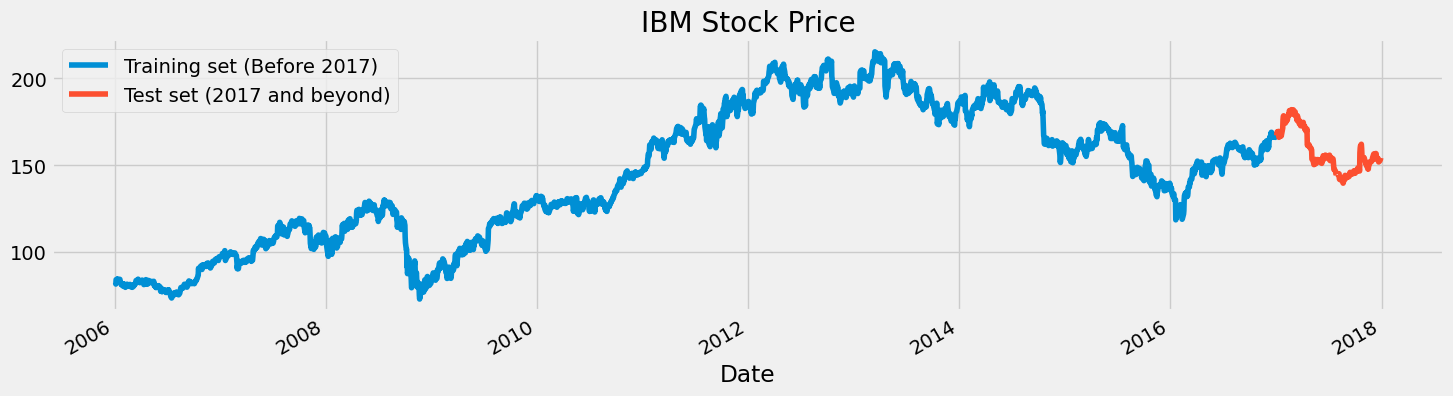

In [ ]:
# Plotting the training and test sets
dataset[:'2016']["Open"].plot(figsize=(16, 4), legend=True) # Training set
dataset['2017':]["Open"].plot(figsize=(16, 4), legend=True) # Test set
plt.legend(['Training set (Before 2017)', 'Test set (2017 and beyond)'])
plt.title('IBM Stock Price')
plt.show()

### Scaling the values

In [ ]:
# Scaling the training set
sc = MinMaxScaler(feature_range=(0, 1))
training_set_scaled = sc.fit_transform(training_set.reshape(-1, 1))

## Preparing the data for RNNs

In [ ]:
# Creating the data structure with 60 timesteps
X_train = []
y_train = []
for i in range(60, len(training_set)):
    X_train.append(training_set_scaled[i-60:i])
    y_train.append(training_set_scaled[i])
X_train, y_train = np.array(X_train), np.array(y_train)

# Reshaping X_train for efficient modeling
# X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [ ]:
X_train.shape

(2709, 60, 1)

## Building and Training the LSTM Model

In [ ]:
# Building the LSTM model
regressor = Sequential()

# First LSTM layer with Dropout regularization
regressor.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
regressor.add(Dropout(0.2))

# Second LSTM layer
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))

# Third LSTM layer
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))

# Fourth LSTM layer
regressor.add(LSTM(units=50))
regressor.add(Dropout(0.2))

# Output layer
regressor.add(Dense(units=1))

# Compiling the model
regressor.compile(optimizer='rmsprop', loss='mean_squared_error')

# Training the model
history = regressor.fit(X_train, y_train, epochs=50, batch_size=32)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0219
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0103
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0085
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0074
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0064
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0059
Epoch 7/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0051
Epoch 8/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0048
Epoch 9/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0044
Epoch 10/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0041
Epoch 11/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0041
Epoch 12/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0037
Epoch 13/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0036
Epoch 14/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0033
Epoch 15/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0032
Epoc

## Making predictions with the model

In [ ]:
# Preparing the test set
dataset_total = pd.concat((dataset["High"][:'2016'], dataset["High"]['2017':]), axis=0)
inputs = dataset_total[len(dataset_total) - len(test_set) - 60:].values
inputs = inputs.reshape(-1, 1)
inputs = sc.transform(inputs)

# Preparing X_test
X_test = []
for i in range(60, 311):
    X_test.append(inputs[i-60:i])
X_test = np.array(X_test)
# X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Making predictions
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step


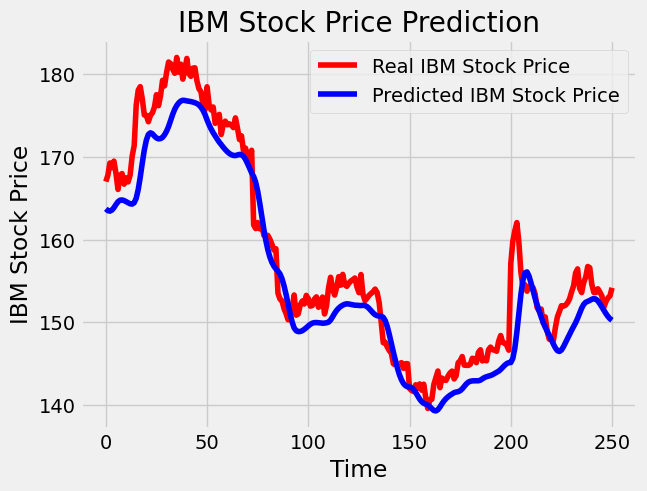

In [ ]:
# Plotting the results
def plot_predictions(test, predicted):
    plt.plot(test, color='red', label='Real IBM Stock Price')
    plt.plot(predicted, color='blue', label='Predicted IBM Stock Price')
    plt.title('IBM Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('IBM Stock Price')
    plt.legend()
    plt.show()

plot_predictions(test_set, predicted_stock_price)